In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/DWDM_Project/data/processed/samsung_processed_dataset.csv")

df.head()

,Product,Category,Rating,Review,Platform,Date,Issue,RSI,Sentiment_score
0,Samsung Buds Live,Accessories,5,worth it house save decide although bag fight ...,Flipkart,2024-12-14,none,0.0600,0.5859
1,Samsung Galaxy M14,Smartphone,2,waste of money issue display flickering,Flipkart,2022-07-04,display,0.6536,-0.4215
2,Samsung Galaxy M53,Smartphone,5,excellent game threat see head cover task see,Flipkart,2022-07-21,none,0.0600,0.0772
3,Samsung Galaxy Tab A8,Smartphone,4,good,Amazon,2024-03-13,none,0.1350,0.4404
4,Samsung Charger 25W,Accessories,1,average join hotel daughter water,Flipkart,2024-11-13,heating,0.5600,0.2960


In [4]:
df["Positive"] = (df["RSI"] < 0.3).astype(int)

df["Positive"].value_counts()

,count
Positive,
0,3937
1,3557


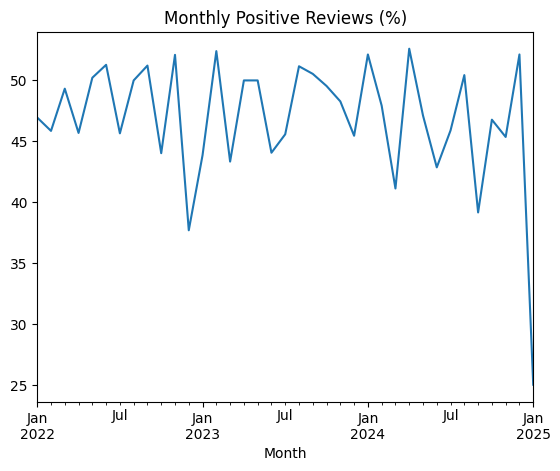

In [5]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period("M")

monthly_positive = df.groupby("Month")["Positive"].mean() * 100

monthly_positive.plot(title="Monthly Positive Reviews (%)")
plt.show()

In [6]:
top_positive_products = df.groupby("Product")["Positive"].mean().sort_values(ascending=False).head(10)

print(top_positive_products)

Product
 Samsung Galaxy M53           0.586957
 Samsung Refrigerator         0.538462
 Samsung Galaxy Tab S7 FE     0.533333
 Samsung Galaxy S23           0.533333
 Samsung QLED TV              0.529412
Samsung Charger 25W           0.516717
Samsung Galaxy M34            0.508361
 Samsung Buds Live            0.503185
Samsung Galaxy A34            0.501661
Samsung Galaxy M53            0.493865
Name: Positive, dtype: float64


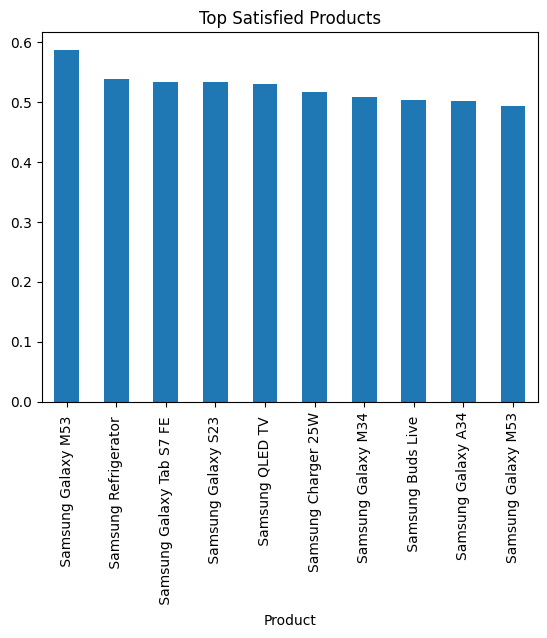

In [7]:
top_positive_products.plot(kind="bar", title="Top Satisfied Products")
plt.show()

Platform
Amazon      46.686031
Flipkart    48.260049
Name: Positive, dtype: float64


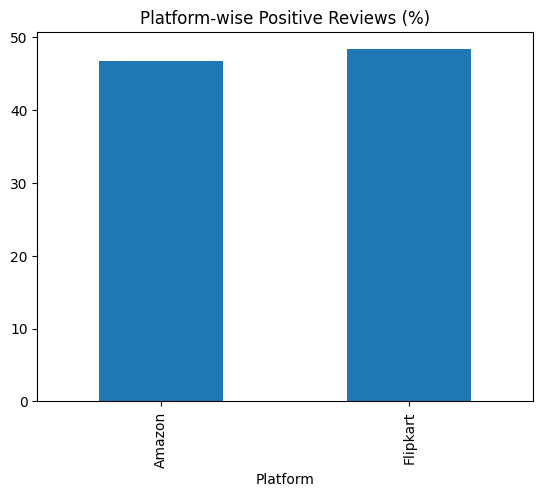

In [8]:
platform_positive = df.groupby("Platform")["Positive"].mean() * 100

print(platform_positive)

platform_positive.plot(kind="bar", title="Platform-wise Positive Reviews (%)")
plt.show()

Category
Smartphone     0.477031
Accessories    0.475702
TV             0.411765
Other          0.389313
Name: Positive, dtype: float64


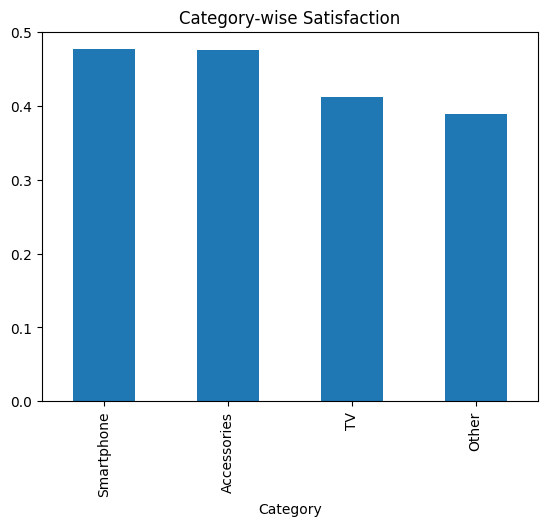

In [9]:
category_positive = df.groupby("Category")["Positive"].mean().sort_values(ascending=False)

print(category_positive)

category_positive.plot(kind="bar", title="Category-wise Satisfaction")
plt.show()

In [17]:
positive_reviews = df[df["Positive"] == 1].copy()

avg_sentiment = positive_reviews["Sentiment_score"].mean()

print("Average Sentiment (Positive Reviews):", avg_sentiment)

Average Sentiment (Positive Reviews): 0.22444523474838346


In [12]:
happy_reasons = positive_reviews["Issue"].value_counts().head(5)

print(happy_reasons)

Issue
none        3421
software      45
camera        25
sound         15
heating       11
Name: count, dtype: int64


In [15]:
def extract_positive_reason(text):
    text = str(text).lower()

    reason_map = {
        "performance": ["fast", "smooth", "speed", "lag free", "quick"],
        "battery": ["battery good", "long battery", "backup", "lasting"],
        "camera": ["camera good", "clear photo", "quality photo"],
        "display": ["display good", "bright", "clear screen"],
        "value_for_money": ["worth", "value", "price", "budget", "cheap"],
        "build_quality": ["premium", "strong", "design", "look", "finish"],
        "sound": ["sound good", "audio clear", "loud"],
        "overall_good": ["good", "excellent", "best", "awesome", "perfect"]
    }

    scores = {}

    for reason, keywords in reason_map.items():
        score = sum(word in text for word in keywords)
        if score > 0:
            scores[reason] = score

    if scores:
        return max(scores, key=scores.get)

    return "general_positive"

In [19]:
positive_reviews["Positive_Reason"] = positive_reviews["Review"].apply(extract_positive_reason)

In [20]:
reason_counts = positive_reviews["Positive_Reason"].value_counts()

print(reason_counts)

Positive_Reason
general_positive    1520
overall_good        1269
value_for_money      668
build_quality         64
performance           36
Name: count, dtype: int64


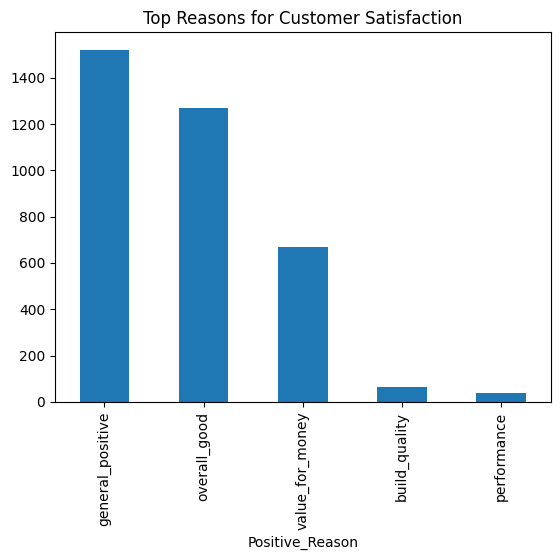

In [21]:
reason_counts.head(8).plot(kind="bar", title="Top Reasons for Customer Satisfaction")
plt.show()

In [22]:
top_positive_products.to_csv("/content/drive/MyDrive/DWDM_Project/outputs/top_positive_products.csv")